In [2]:
# Importing all necessary libraries
# For Data manipulation
import pandas as pd
import numpy as np

# For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# To Save model
import joblib

# To deal with warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Loading Dataset
# Since the given dataset is in excel, we need to change it to comma seperated value and save it in folder. 
df_temp = pd.read_excel("data/raw/Online_Retail.xlsx")
df_temp.to_csv("data/raw/Online_Retail.csv", index=False)
df = pd.read_csv("data/raw/Online_Retail.csv")

In [5]:
# Basic Data Inspection
# To Check dataset information
df.info()

# To find Summary statistics
df.describe()

# Checking  missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Checking the Dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
# Finding Number ofUnique values per Column
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [8]:
# Data Cleaning 
# Removing Rows Customer column avlue is NuLL
df = df.dropna(subset=['CustomerID'])
# Formatting the Date Column to convert string to datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Removing Negative Quantites since negative quantities usually represent returns or cancellations if a customer has both therefore it will confuse the model
df = df[df['Quantity'] > 0]
# Removing Zero or Negative Price as if price is zero or less it simply means no money was spend by customer
df = df[df['UnitPrice'] > 0]
# Removing Duplicates 
df = df.drop_duplicates()

In [10]:
# Feature Engineering 
# Creating a total transaction value
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [11]:
# RMF Feature Creation 
# Converting Transactions to Customer Behavio Features
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [12]:
# Feature Scaling 
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm.columns)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.397035,8.363010
1,-0.905340,0.405694,0.251699
2,-0.175360,-0.263986,-0.027988
3,-0.735345,-0.077717,-0.032406
4,2.174578,-0.326075,-0.190812


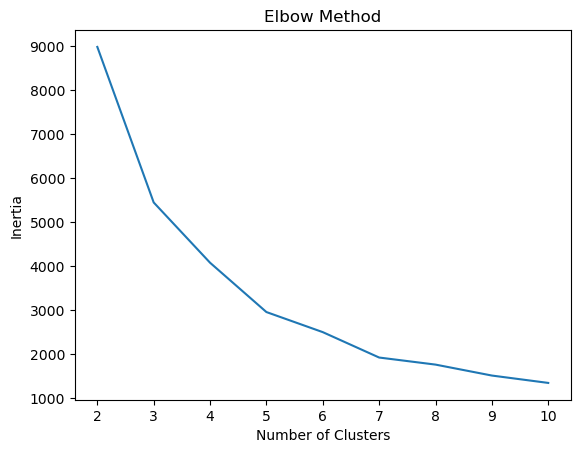

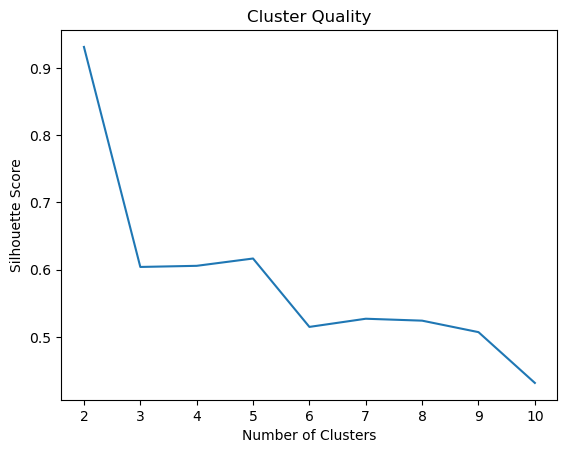

In [24]:
# Trying to find number of clusters sufficient using elbow method and silhouette score
inertia = []
silhouette_scores = []

for k in range(2,11):

    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(rfm_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

# Plotting the elbow curve
plt.plot(range(2,11), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Ploting the silhouette score
plt.plot(range(2,11), silhouette_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Cluster Quality")
plt.show()

In [34]:
# Creating a pipeline to standarise data and clustering with k = 3 for simple interptobality 
pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("kmeans", KMeans(
        n_clusters=3,
        random_state=42
    ))

])

In [35]:
# Training the model 
pipeline.fit(rfm)

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [36]:
# Assigning Cluster Labels 
# Predicting cluster for each customer
clusters = pipeline.predict(rfm)

# Adding a cluster column
rfm["Cluster"] = clusters

# Finding the Number of customers in each cluster
rfm["Cluster"].value_counts()

Cluster
0    3245
2    1079
1      14
Name: count, dtype: int64

In [38]:
# Cluster Profiling 
# Finding out which cluster goes to which 
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,41.421572,100.931895,2019.215828
1,4.428571,2546.000000,117845.255000
2,247.403151,27.362373,634.865580


In [44]:
# From the above statistics we can infer that cluster 0 is of loyal customers while one is for champion customer and two is for at risk customer as for : 
# 0 : They have a recency of 41 days and a spending of $2019 with a moderate frequency
# 1 : They have a very low recency, high frequency and very high spending
# 2 : They have a very high recency meaning that either they are very irregeular or one time customer only with low frequency and low monetary spending

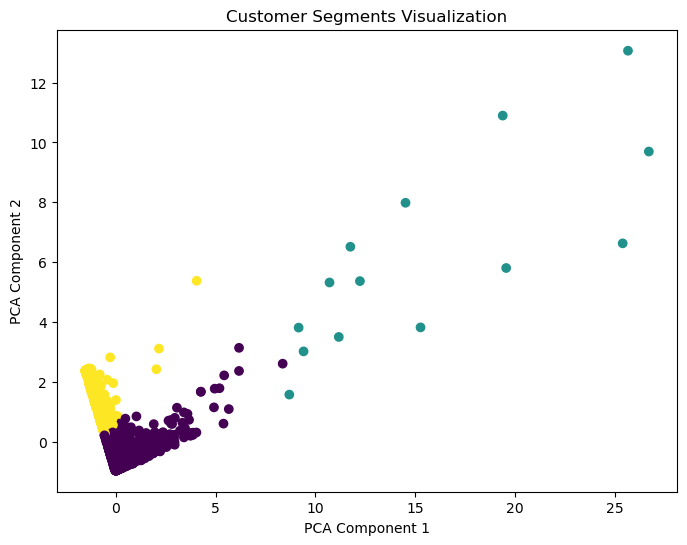

In [45]:
# PCA Visualization 
# Remove cluster column for PCA
features = rfm.drop("Cluster", axis=1)

# Scale data
scaled_features = StandardScaler().fit_transform(features)

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=rfm["Cluster"],
    cmap="viridis"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("Customer Segments Visualization")

plt.show()

In [47]:
# Calculating the quality of clusters  
score = silhouette_score(scaled_features, rfm["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.6032885685633959


In [48]:
# Saving the pipeline 
joblib.dump(pipeline, "customer_segmentation_pipeline.pkl")


['customer_segmentation_pipeline.pkl']